# LungLens — Full Fine-tuning (Differential Learning Rates)

**Goal:** fine-tune **all 11.2M params** of ResNet-18 with:
- **Differential LRs** — layer1–2: `1e-5`, layer3–4: `1e-4`, fc head: `1e-3`
- Data augmentation (flips, rotation, color jitter, random crop)
- AdamW + CosineAnnealing scheduler
- **Early stopping** on val_acc (patience=5), max 20 epochs

Outputs: `results/finetune_history.json`, exported model for the FastAPI app (`saved_models/lunglens_resnet18.pt`), and the **baseline vs fine-tune comparison** artifacts.

> Run the baseline notebook first. Expected time: ~40–60 min on a T4.

In [1]:
!pip install -q pytorch-lightning torchmetrics opendatasets

In [2]:
import json, time, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, models, transforms
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
import torchmetrics

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
pl.seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path("saved_models"); MODELS_DIR.mkdir(exist_ok=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cuda


In [3]:
# --- Download dataset (same as baseline notebook) ---
import opendatasets as od

DATASET_URL = "https://www.kaggle.com/datasets/raunakgola/radiography-dataset-covid"
if not Path("radiography-dataset-covid").exists():
    od.download(DATASET_URL)
else:
    print("Dataset already downloaded, skipping...")

TRAIN_DIR = next(Path("radiography-dataset-covid").rglob("Train"))
TEST_DIR = TRAIN_DIR.parent / "Test"
print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)

Dataset already downloaded, skipping...
Train: radiography-dataset-covid/COVID-19_Radiography_Dataset/Train
Test : radiography-dataset-covid/COVID-19_Radiography_Dataset/Test


In [4]:
# --- Data: augmentation for train, clean transforms for val/test ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH_SIZE = 128
NUM_WORKERS = 2

# Two ImageFolder views of the SAME data (aug vs clean), split with the SAME seed
# as the baseline notebook -> identical train/val split for a fair comparison.
train_view = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
eval_view = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)
CLASS_NAMES = train_view.classes
NUM_CLASSES = len(CLASS_NAMES)

idx = torch.randperm(len(train_view), generator=torch.Generator().manual_seed(SEED)).tolist()
n_val = int(0.1 * len(train_view))
val_idx, train_idx = idx[:n_val], idx[n_val:]
train_ds = Subset(train_view, train_idx)
val_ds = Subset(eval_view, val_idx)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {CLASS_NAMES}")

Train: 15237 | Val: 1693 | Test: 4235
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [5]:
# --- LightningModule: ALL layers trainable, differential learning rates ---
class LungLensFinetune(pl.LightningModule):
    def __init__(self, num_classes: int, head_lr=1e-3, mid_lr=1e-4, low_lr=1e-5,
                 weight_decay=1e-4, max_epochs=20):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        # NOTE: nothing is frozen — every parameter trains
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.train_acc(out, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.val_acc(out, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True)

    def test_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.test_acc(out, y)
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_acc", self.test_acc, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        m = self.model
        # Differential LRs: earliest layers move least (generic features),
        # later layers more (task-specific), fresh head the most.
        param_groups = [
            {"params": [*m.conv1.parameters(), *m.bn1.parameters(),
                        *m.layer1.parameters(), *m.layer2.parameters()],
             "lr": self.hparams.low_lr},
            {"params": [*m.layer3.parameters(), *m.layer4.parameters()],
             "lr": self.hparams.mid_lr},
            {"params": m.fc.parameters(), "lr": self.hparams.head_lr},
        ]
        optimizer = optim.AdamW(param_groups, weight_decay=self.hparams.weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.hparams.max_epochs)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


MAX_EPOCHS = 20
model = LungLensFinetune(num_classes=NUM_CLASSES, max_epochs=MAX_EPOCHS)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")

Total params:     11,178,564
Trainable params: 11,178,564  (100.0%)


In [6]:
# --- Train with early stopping ---
checkpoint_cb = ModelCheckpoint(
    dirpath=MODELS_DIR, filename="finetune-best",
    monitor="val_acc", mode="max", save_top_k=1,
)
early_stop_cb = EarlyStopping(monitor="val_acc", mode="max", patience=5, verbose=True)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    precision="16-mixed" if DEVICE == "cuda" else "32-true",
    callbacks=[checkpoint_cb, early_stop_cb, LearningRateMonitor(logging_interval="epoch")],
    logger=CSVLogger("lightning_logs", name="finetune"),
)

start = time.time()
trainer.fit(model, train_dl, val_dl)
train_minutes = (time.time() - start) / 60
print(f"\nTraining took {train_minutes:.1f} min (stopped at epoch {trainer.current_epoch})")
print(f"Best val_acc: {checkpoint_cb.best_model_score:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/saved_models exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits inst

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.714                                                                     
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.008 >= min_delta = 0.0. New best score: 0.935


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.942


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_acc improved by 0.001 >= min_delta = 0.0. New best score: 0.943


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_acc did not improve in the last 5 records. Best score: 0.943. Signaling Trainer to stop.



Training took 21.3 min (stopped at epoch 11)
Best val_acc: 0.9433


In [7]:
# --- Evaluate best checkpoint on test set ---
test_metrics = trainer.test(model, test_dl, ckpt_path="best")[0]
print(test_metrics)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/saved_models/finetune-best.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/saved_models/finetune-best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9383707046508789     │
│         test_loss         │    0.48875510692596436    │
└───────────────────────────┴───────────────────────────┘

{'test_loss': 0.48875510692596436, 'test_acc': 0.9383707046508789}


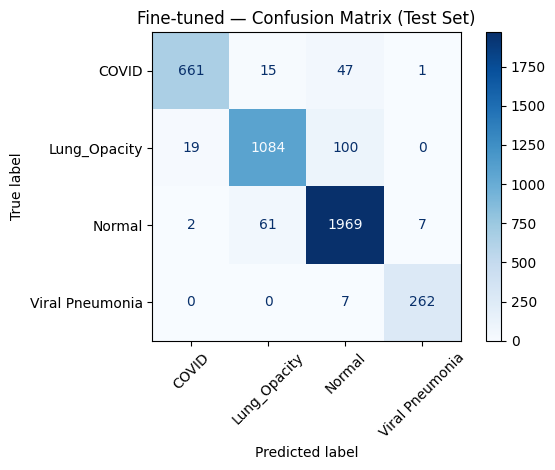

                 precision    recall  f1-score   support

          COVID       0.97      0.91      0.94       724
   Lung_Opacity       0.93      0.90      0.92      1203
         Normal       0.93      0.97      0.95      2039
Viral Pneumonia       0.97      0.97      0.97       269

       accuracy                           0.94      4235
      macro avg       0.95      0.94      0.94      4235
   weighted avg       0.94      0.94      0.94      4235



In [8]:
# --- Confusion matrix + classification report ---
best = LungLensFinetune.load_from_checkpoint(checkpoint_cb.best_model_path)
best.eval().to(DEVICE)

preds_list, labels_list = [], []
with torch.no_grad():
    for X, y in test_dl:
        out = best(X.to(DEVICE))
        preds_list.append(out.argmax(1).cpu().numpy())
        labels_list.append(y.numpy())
preds = np.concatenate(preds_list); labels = np.concatenate(labels_list)

cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Fine-tuned — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "finetune_confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(labels, preds, target_names=CLASS_NAMES))

In [9]:
# --- Save history + export model for the FastAPI app ---
metrics_csv = Path(trainer.logger.log_dir) / "metrics.csv"
mdf = pd.read_csv(metrics_csv)
by_epoch = mdf.groupby("epoch").last()

history = {
    "mode": "finetune",
    "model": "resnet18 (all layers, differential LRs)",
    "dataset": "COVID-19 Radiography (Kaggle: raunakgola/radiography-dataset-covid)",
    "class_names": CLASS_NAMES,
    "seed": SEED,
    "epochs_run": int(by_epoch.index.max()) + 1,
    "max_epochs": MAX_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lrs": {"layer1_2": 1e-5, "layer3_4": 1e-4, "fc": 1e-3},
    "augmentation": True,
    "scheduler": "CosineAnnealingLR",
    "early_stopping": "val_acc, patience=5",
    "label_smoothing": 0.1,
    "total_params": total,
    "trainable_params": trainable,
    "train_minutes": round(train_minutes, 1),
    "train_loss": by_epoch["train_loss"].dropna().tolist(),
    "train_acc": by_epoch["train_acc"].dropna().tolist(),
    "val_loss": by_epoch["val_loss"].dropna().tolist(),
    "val_acc": by_epoch["val_acc"].dropna().tolist(),
    "best_val_acc": float(checkpoint_cb.best_model_score),
    "test_acc": float(test_metrics["test_acc"]),
    "test_loss": float(test_metrics["test_loss"]),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}

with open(RESULTS_DIR / "finetune_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"FINE-TUNED TEST ACCURACY: {history['test_acc']*100:.2f}%")

# Export a plain state_dict (what the FastAPI app loads — no Lightning needed at serve time)
torch.save(best.model.state_dict(), MODELS_DIR / "lunglens_resnet18.pt")
with open(MODELS_DIR / "classes.json", "w") as f:
    json.dump(CLASS_NAMES, f)
print("Exported saved_models/lunglens_resnet18.pt + classes.json")

FINE-TUNED TEST ACCURACY: 93.84%
Exported saved_models/lunglens_resnet18.pt + classes.json


# LungLens — Baseline vs Fine-tuned

| Metric | Baseline (frozen) | Fine-tuned (all layers) |
|---|---|---|
| Test accuracy | 85.10% | 93.84% |
| Best val accuracy | 84.76% | 94.33% |
| Trainable params | 2,052 | 11,178,564 |
| Epochs run | 11 | 12 |
| Train time (min) | 11.4 | 21.3 |
| Augmentation | False | True |
| Scheduler | None | CosineAnnealingLR |

**Absolute accuracy gap: +8.74 percentage points** | Relative improvement: +10.3%



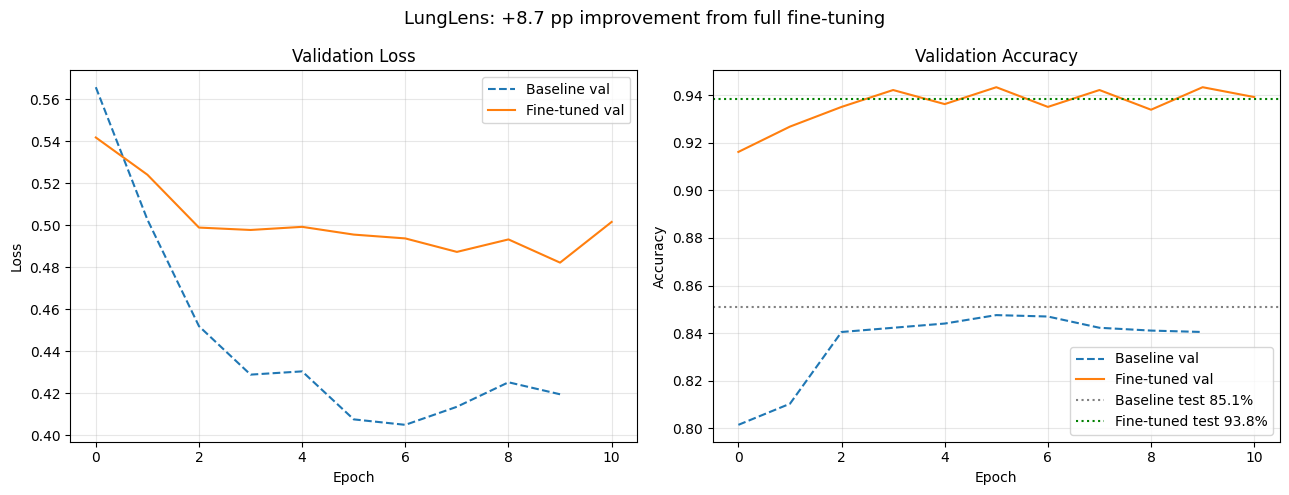

In [10]:
# --- Baseline vs Fine-tuned comparison (needs results/baseline_history.json) ---
baseline_path = RESULTS_DIR / "baseline_history.json"
if not baseline_path.exists():
    raise FileNotFoundError("Run 01_baseline_training.ipynb first (or upload baseline_history.json to results/)")

with open(baseline_path) as f:
    base = json.load(f)
ft = history

gap = (ft["test_acc"] - base["test_acc"]) * 100
rel = (ft["test_acc"] - base["test_acc"]) / base["test_acc"] * 100

rows = [
    ("Test accuracy", f"{base['test_acc']*100:.2f}%", f"{ft['test_acc']*100:.2f}%"),
    ("Best val accuracy", f"{base['best_val_acc']*100:.2f}%", f"{ft['best_val_acc']*100:.2f}%"),
    ("Trainable params", f"{base['trainable_params']:,}", f"{ft['trainable_params']:,}"),
    ("Epochs run", base["epochs_run"], ft["epochs_run"]),
    ("Train time (min)", base["train_minutes"], ft["train_minutes"]),
    ("Augmentation", base["augmentation"], ft["augmentation"]),
    ("Scheduler", base["scheduler"], ft["scheduler"]),
]

md = "# LungLens — Baseline vs Fine-tuned\n\n"
md += "| Metric | Baseline (frozen) | Fine-tuned (all layers) |\n|---|---|---|\n"
for name, b, f_ in rows:
    md += f"| {name} | {b} | {f_} |\n"
md += f"\n**Absolute accuracy gap: +{gap:.2f} percentage points** | Relative improvement: +{rel:.1f}%\n"
with open(RESULTS_DIR / "comparison.md", "w") as f:
    f.write(md)
print(md)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(base["val_loss"], "--", label="Baseline val")
ax1.plot(ft["val_loss"], label="Fine-tuned val")
ax1.set(title="Validation Loss", xlabel="Epoch", ylabel="Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(base["val_acc"], "--", label="Baseline val")
ax2.plot(ft["val_acc"], label="Fine-tuned val")
ax2.axhline(base["test_acc"], color="gray", ls=":", label=f"Baseline test {base['test_acc']*100:.1f}%")
ax2.axhline(ft["test_acc"], color="green", ls=":", label=f"Fine-tuned test {ft['test_acc']*100:.1f}%")
ax2.set(title="Validation Accuracy", xlabel="Epoch", ylabel="Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle(f"LungLens: +{gap:.1f} pp improvement from full fine-tuning", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison.png", dpi=150)
plt.show()

In [11]:
# --- Zip everything to download back into the local repo ---
with zipfile.ZipFile("lunglens_artifacts.zip", "w") as zf:
    for p in RESULTS_DIR.iterdir():
        zf.write(p)
    zf.write(MODELS_DIR / "lunglens_resnet18.pt")
    zf.write(MODELS_DIR / "classes.json")
print("Created lunglens_artifacts.zip — download and extract into your local lung-lens/ folder")
# In Colab:  from google.colab import files; files.download('lunglens_artifacts.zip')

Created lunglens_artifacts.zip — download and extract into your local lung-lens/ folder


In [12]:
from google.colab import drive
drive.mount('/content/drive')
!cp lunglens_artifacts.zip /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
